In [60]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
url = "https://raw.githubusercontent.com/nkmwicz/data-for-students/refs/heads/main/soccer-players.csv"
df = pd.read_csv(url)

In [61]:
df.columns

Index(['player_id', 'first_name', 'last_name', 'name', 'last_season',
       'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth',
       'country_of_citizenship', 'date_of_birth', 'sub_position', 'position',
       'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name',
       'image_url', 'url', 'current_club_domestic_competition_id',
       'current_club_name', 'market_value_in_eur',
       'highest_market_value_in_eur'],
      dtype='object')

In [62]:
df = df[["name", "country_of_birth", "date_of_birth", "position", "height_in_cm"]]
df.head()

,name,country_of_birth,date_of_birth,position,height_in_cm
0,Miroslav Klose,Poland,1978-06-09 00:00:00,Attack,184.0
1,Roman Weidenfeller,Germany,1980-08-06 00:00:00,Goalkeeper,190.0
2,Dimitar Berbatov,Bulgaria,1981-01-30 00:00:00,Attack,NaN
3,Lúcio,Brazil,1978-05-08 00:00:00,Defender,NaN
4,Tom Starke,East Germany (GDR),1981-03-18 00:00:00,Goalkeeper,194.0


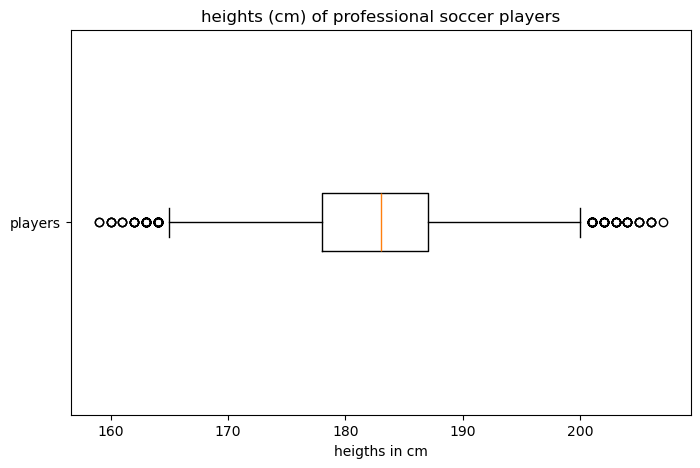

In [63]:
plt.figure(figsize=(8,5))
plt.boxplot(df.loc[df["height_in_cm"] > 150, "height_in_cm"].dropna(), vert=False)
plt.title("heights (cm) of professional soccer players")
plt.xlabel("heigths in cm")
plt.yticks(ticks=[1], labels=["players"])
plt.show()

([<matplotlib.axis.XTick at 0x17b028f50>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5')])

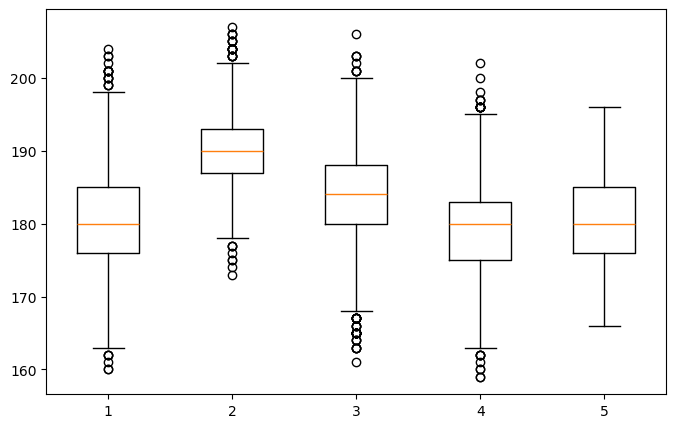

In [64]:
plt.figure(figsize=(8,5))
pos = df["position"].unique()
df = df.loc[df["height_in_cm"]>150]
data = [df.loc[df["position"] == p, "height_in_cm"].dropna() for p in pos]
plt.boxplot(x=data, positions=range(1, len(pos)+1))
# for idx p in enumerate(pos):
#    data = df.loc[df["height_in_cm"] > 150]
#    data = df.loc[df["position"] == p, "height_in_cm"].dropna()
#    plt.boxplot(data)
plt.xticks(ticks=range(1, len(pos)+1), label=pos.tolist())

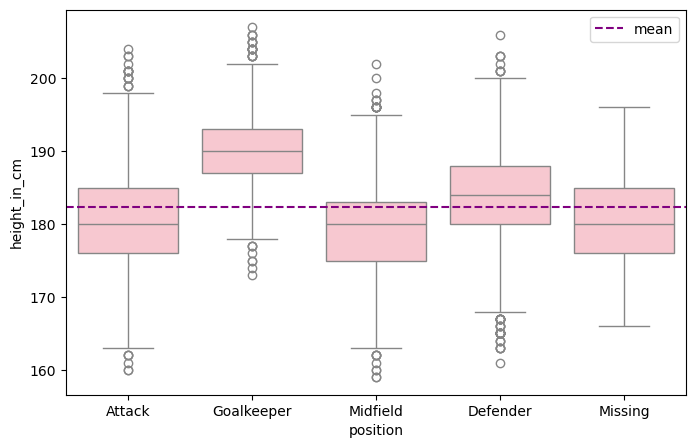

In [65]:
plt.figure(figsize=(8,5))
df = df.loc[df["height_in_cm"]>150]
ht_boxes = sns.boxplot(data=df, x = "position", y = "height_in_cm", color = "pink")
plt.axhline(y=df["height_in_cm"].mean(), color = "purple", linestyle= "--", label="mean")
plt.legend()
plt.show()

In [69]:
import scipy.stats as stats

def multiplot(df: pd.DataFrame, col:str, xlabel=str):
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, height_ratios=[2,8])
    box = sns.boxplot(data=df, x = col, ax=ax1, color = "lightblue")
    hist = sns.histplot(data=df, x = col, ax=ax2, color = "lightblue", kde=True)
    sk = stats.skew(df[col], nan_policy="omit")
    kurt = stats.kurtosis(df[col], nan_policy="omit")
    box.set(xlabel = "", xticks=[], yticks=[])
    ax1.spines["bottom"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.spines["left"].set_visible(False)
    ax1.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    hist.set(xlabel = xlabel)
    text = f"skew: {sk: .3f}\nkurtosis: {kurt: .3f}"
    plt.text(
        x=0.2,
        y=0.7,
        s=text,
        transform = plt.gca().transAxes,
        bbox = {"boxstyle": "round, pad = 0.5", "fc":"white"},
        ha = "center"
    )
    plt.show()

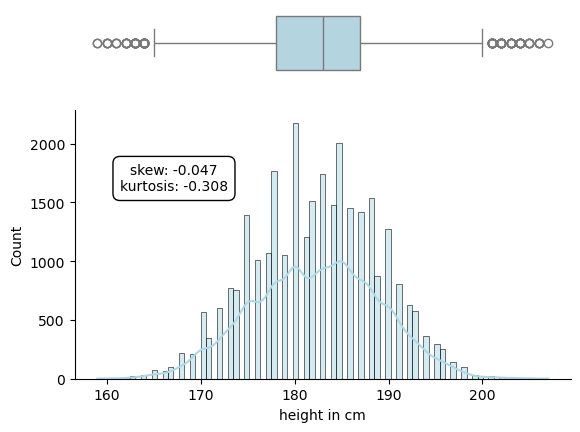

In [67]:
multiplot(df=df, col="height_in_cm", xlabel="height in cm")

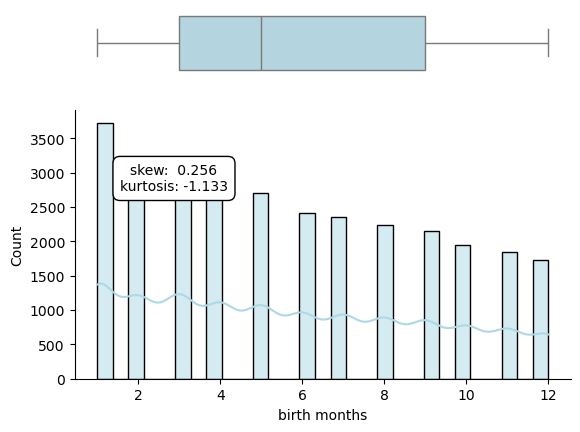

In [70]:
df["month"] = pd.to_datetime(df["date_of_birth"]).dt.month
multiplot(df=df, col = "month", xlabel = "birth months")